# PCA — Image Generation

Generate **new** images with a simple *linear-Gaussian* generative model:

1. Fit a **PCA** to compress the 28x28 images into a modest latent space.
2. Fit a **Gaussian** to the latent codes — **one per class**.
3. **Sample** fresh latent vectors from each Gaussian and `inverse_transform`
   them back to pixel space.

The reusable helpers live in [`utils/pca/generation.py`](../utils/pca/generation.py);
this notebook imports and demonstrates them on two datasets, using the whole of each:

- **Part 1 — MNIST** digits `0 / 1 / 2` ([`utils/mnist_data.py`](../utils/mnist_data.py))
- **Part 2 — Quick, Draw!** sketches `cat / apple / car` ([`utils/data_import.py`](../utils/data_import.py))

Both share the same `(n, 784)`, `[0, 1]` contract, so the generator runs unchanged on either — only the loader differs.

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the kernel starts at the repo root, in src/,
# or in src/pca/.
for cand in (Path.cwd(), *Path.cwd().parents):
    if (cand / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand)); break
    if (cand / "src" / "utils" / "mnist_data.py").exists():
        sys.path.insert(0, str(cand / "src")); break

from utils.mnist_data import load_digits, DIGITS
from utils.data_import import load_sketches, CLASSES
from utils.pca.dim_reduction import fit_pca, plot_eigenimages
from utils.pca.generation import (
    fit_latent_gaussian, plot_generated_grid, plot_real_vs_generated, plot_interpolation,
)

# Per-class sample cap. MNIST's classes are all smaller than this, so every
# training image is used; Quick, Draw!'s much larger categories are capped to it.
PER_CLASS = 10000
DIGITS, CLASSES

((0, 1, 2), ['cat', 'apple', 'car'])

# Part 1 — MNIST digits (0 / 1 / 2)

## Load the data

MNIST's training split contains 5 923 `0`s, 6 742 `1`s and 5 958 `2`s. The
loader caps each class at `PER_CLASS = 10 000` samples; since every class holds
fewer than that, all **18 623** training images are used — a flat, `[0, 1]`-scaled
`(18623, 784)` matrix `X` and its integer label vector `y`.

In [2]:
X, y = load_digits(per_class=PER_CLASS)
X.shape, y.shape, sorted(set(y.tolist()))

I0000 00:00:1784153810.984497   24955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784153811.051187   24955 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784153812.760065   24955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


((18623, 784), (18623,), [0, 1, 2])

## Fit PCA

We reduce to **50 components** — enough to capture the bulk of the pixel
variance while keeping the latent space small enough to model with a Gaussian.

In [3]:
N_COMPONENTS = 50
pca = fit_pca(X, n_components=N_COMPONENTS)
print(f"latent dim = {pca.n_components_}")
print(f"explained variance retained = {pca.explained_variance_ratio_.sum():.3f}")

latent dim = 50
explained variance retained = 0.867


## Fit a Gaussian per class

`fit_latent_gaussian(pca, X, y=y)` returns a `{label: (mean, cov)}` dict — one
multivariate Gaussian fitted to the latent codes of each digit. A tiny ridge is
added to each covariance diagonal so it is safe to sample from.

In [4]:
per_class = fit_latent_gaussian(pca, X, y=y)
{f"digit {label}": (m.shape, cov.shape) for label, (m, cov) in per_class.items()}

{'digit 0': ((50,), (50, 50)),
 'digit 1': ((50,), (50, 50)),
 'digit 2': ((50,), (50, 50))}

## Generate new digits

For each class we sample latent vectors from its Gaussian, decode them with
`generate`, and show a grid. These are **synthetic** digits — not copies of any
training image.

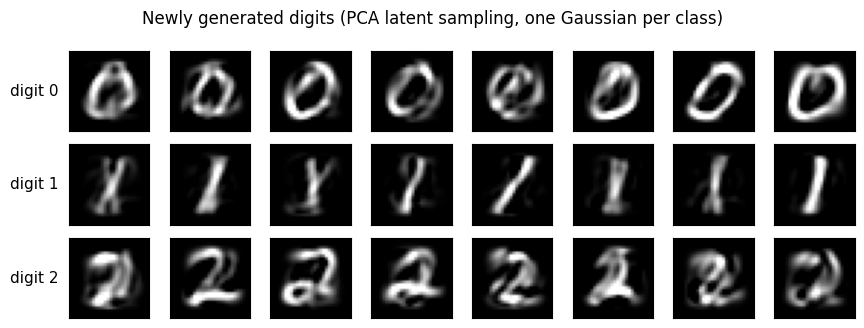

In [5]:
plot_generated_grid(pca, per_class, [f"digit {d}" for d in DIGITS],
                    suptitle="Newly generated digits (PCA latent sampling, one Gaussian per class)")

## Real vs. generated

A quick sanity check: the class means decode to clean "prototype" digits, and
the samples scatter around them.

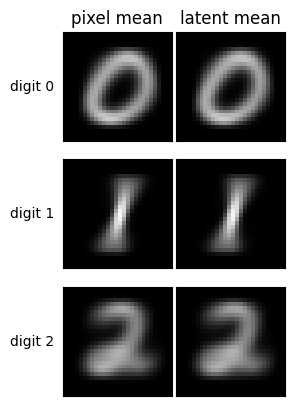

In [6]:
plot_real_vs_generated(pca, X, y, per_class, [f"digit {d}" for d in DIGITS])

## The generative basis, and the centering choice

Sampling happens in the 50-D PCA latent space, so the model builds every new
digit as **the mean image plus a weighted mix of the principal components**.
Those components are the axes the samples move along — worth seeing directly:

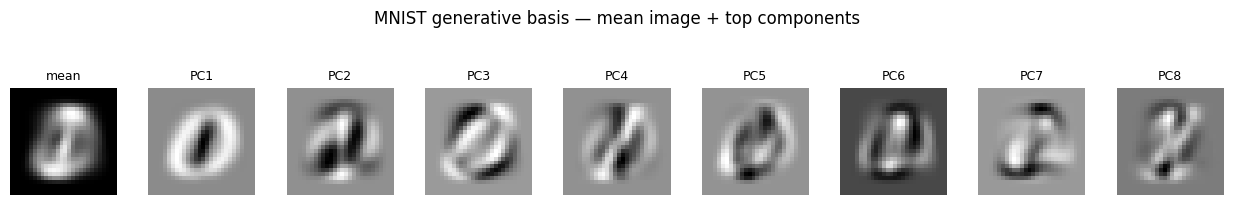

In [7]:
plot_eigenimages(pca, n=8, suptitle="MNIST generative basis — mean image + top components")

**Two means, for generation.** What if we build the latent space with global
centering instead? Unlike dimensionality reduction and compression, generation is
largely *unaffected*: the mean image is restored either way — from `mean_` under
per-feature centering, or from the PC1 that re-encodes it under global centering —
so the decoded digits look about the same. The only real cost is that global
centering spends one of the 50 latent dimensions on the mean image, leaving 49
(instead of 50) to model genuine variation. We regenerate with global centering
to check:

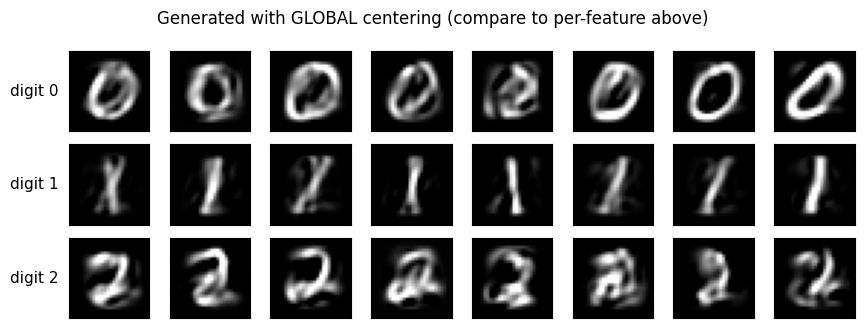

In [8]:
# Rebuild the latent space with global centering, refit the per-class Gaussians, regenerate.
pca_glob = fit_pca(X, n_components=N_COMPONENTS, center="global")
per_class_glob = fit_latent_gaussian(pca_glob, X, y=y)
plot_generated_grid(pca_glob, per_class_glob, [f"digit {d}" for d in DIGITS],
                    suptitle="Generated with GLOBAL centering (compare to per-feature above)")

## Latent-space interpolation

Walking along a straight line between the latent codes of two real digits and
decoding each step shows how the linear latent space morphs one digit into
another.

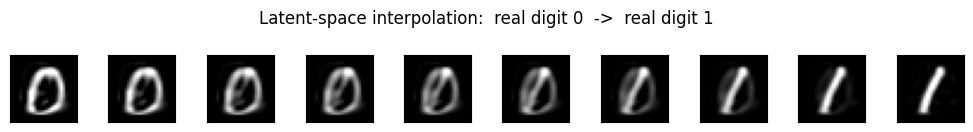

In [9]:
# Morph one real "0" into one real "1" through the linear latent space.
plot_interpolation(pca, X, y, 0, 1, [f"digit {d}" for d in DIGITS])

## What PCA-based generation can and cannot do

**Can:**
- Produce *plausible average-looking* digits cheaply — no iterative training,
  just a fit + a Gaussian sample.
- Capture the dominant, *linear* modes of variation (thickness, slant, overall
  size) that PCA's top components encode.
- Give a smooth, continuous latent space where interpolation stays digit-like.

**Cannot:**
- Capture **nonlinear** structure. Because both the PCA map and the Gaussian are
  linear/quadratic, samples tend toward smooth, slightly blurry "mean" digits
  and miss sharp, localised strokes.
- Model **multimodal** within-class variation well — a single Gaussian assumes
  one blob per class, so distinct writing styles get averaged together.
- Guarantee valid pixels: `inverse_transform` can leave the `[0, 1]` range, so we
  **clip**. Off-manifold samples can look like faint ghosting.

For crisper, more varied digits you'd move to a nonlinear generative model
(e.g. a VAE or GAN); PCA here is the interpretable linear baseline.

# Part 2 — Quick, Draw! sketches (cat / apple / car)

The **same linear-Gaussian generator** is applied to hand-drawn sketches.
`load_sketches` gives the identical `(n, 784)`, `[0, 1]` contract, so `fit_pca`,
`fit_latent_gaussian` and the plotting helpers are reused unchanged — only the
loader differs. Each category holds over 100 000 drawings; the loader caps each
at `PER_CLASS = 10 000`, for a balanced **30 000**-sketch matrix.

Sketches pack far less variance into their top components than digits do, so a
50-D latent space retains a **smaller fraction** of their structure. The
generated sketches are therefore expected to be blurrier, more "average" blobs.

In [10]:
X, y = load_sketches(per_class=PER_CLASS)
print("X", X.shape, "classes", sorted(set(y.tolist())), "->", CLASSES)

# Same 50-D PCA latent space, same per-class Gaussian fit -- only the loader changed.
pca = fit_pca(X, n_components=N_COMPONENTS)
print(f"latent dim = {pca.n_components_}")
print(f"explained variance retained = {pca.explained_variance_ratio_.sum():.3f}")

per_class = fit_latent_gaussian(pca, X, y=y)
{CLASSES[label]: (m.shape, cov.shape) for label, (m, cov) in per_class.items()}

X (30000, 784) classes [0, 1, 2] -> ['cat', 'apple', 'car']


latent dim = 50
explained variance retained = 0.439


{'cat': ((50,), (50, 50)),
 'apple': ((50,), (50, 50)),
 'car': ((50,), (50, 50))}

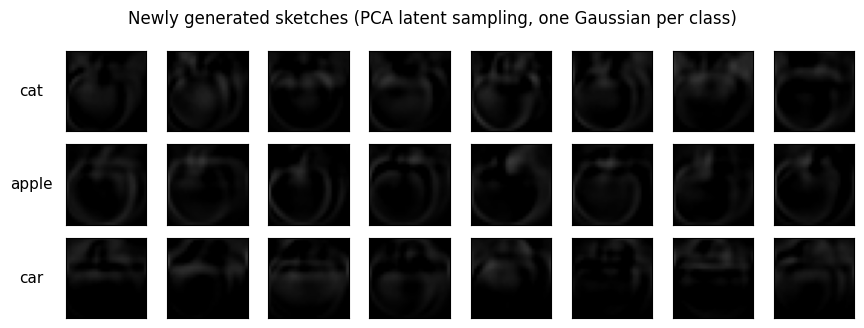

In [11]:
plot_generated_grid(pca, per_class, CLASSES,
                    suptitle="Newly generated sketches (PCA latent sampling, one Gaussian per class)")

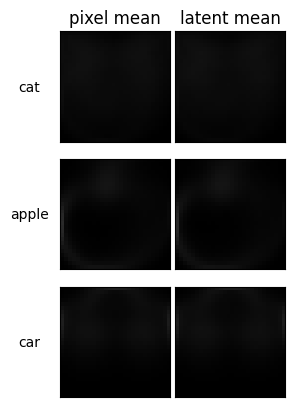

In [12]:
plot_real_vs_generated(pca, X, y, per_class, CLASSES)

The sketch generative basis and its two-means check. The eigen-sketches are the
diffuse blobs we saw before — which is exactly why the samples come out as vague
scribbles. As with MNIST, switching to global centering barely changes the output
(the mean image is restored either way).

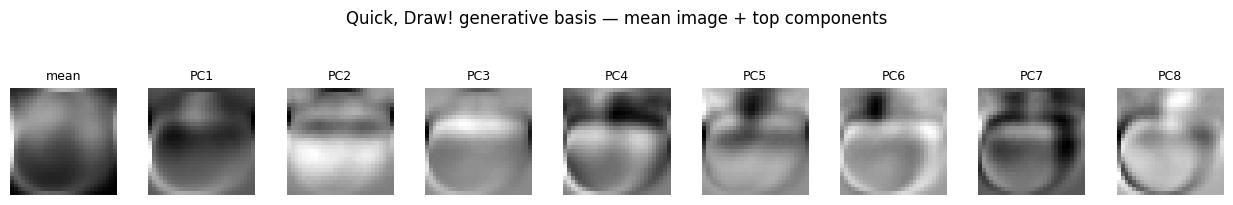

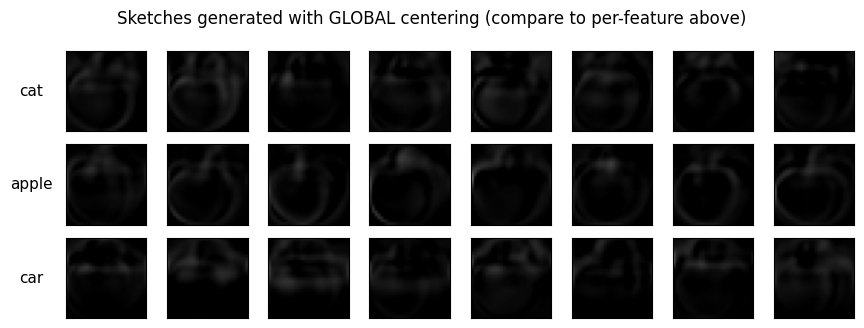

In [13]:
plot_eigenimages(pca, n=8, suptitle="Quick, Draw! generative basis — mean image + top components")

pca_glob = fit_pca(X, n_components=N_COMPONENTS, center="global")
per_class_glob = fit_latent_gaussian(pca_glob, X, y=y)
plot_generated_grid(pca_glob, per_class_glob, CLASSES,
                    suptitle="Sketches generated with GLOBAL centering (compare to per-feature above)")

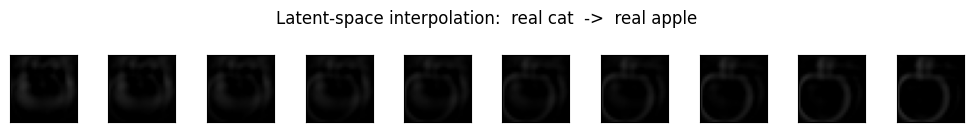

In [14]:
# Morph one real cat into one real apple through the linear latent space.
plot_interpolation(pca, X, y, 0, 1, CLASSES)

## MNIST vs. Quick, Draw! — generation takeaway

The generator's limits show up more starkly on sketches:

- **Blurrier, more "average" samples.** The same 50-D latent space retains 86.7% of MNIST's variance but only 43.9% of the sketches' (see the two "explained variance retained" figures above). With most of a sketch's structure discarded, the decoded samples collapse toward each class's mean blob — a rounded scribble for `cat`, `apple`, `car` — with little of the freehand variety of real drawings.
- **The single-Gaussian assumption bites harder.** Sketches of one object are wildly multimodal (a cat drawn as a face vs. a full body), so fitting one Gaussian per class averages incompatible styles together even more than it does for digits.
- **Interpolation still stays smooth** because the latent space is linear — but the endpoints and midpoints are hazier.

Same conclusion as for digits, amplified: PCA + a Gaussian is an interpretable **linear baseline**. Capturing the sharp, multimodal structure of real sketches needs a nonlinear generative model (VAE, GAN, diffusion).